# 03 — Feature Engineering

Builds the **supervised-learning table** for the products we will model with a
global / ML model — **Tiers A and B** (2,947 products). Tier C is left to simple
baselines and needs no features.

Feature families: **calendar** (week-of-year, month, quarter, cyclical sin/cos),
**seasonal flags**, **lags** (1,2,4,8,12,52 weeks), **rolling** mean/std/median
(4,8,13 weeks), **intermittency** (weeks-since-last-sale, trailing zero-fraction,
trailing mean non-zero demand), and **static** product attributes.

**Leakage rule:** every autoregressive feature at week *t* uses only weeks ≤ t-1.
Rolling features `shift(1)` before rolling. All logic is in `src/features.py`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, features as fe
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
config.ensure_dirs()

## Build the feature table

Reads the step-2 outputs and assembles all features for Tiers A and B. Takes ~15-30s.

In [2]:
df = fe.build_feature_table(("A", "B"))
feats = fe.feature_columns(df)
print(f"rows: {len(df):,} | products: {df[config.COL_PRODUCT9].nunique():,} "
      f"| features: {len(feats)}")
print("tiers:", dict(df.drop_duplicates(config.COL_PRODUCT9)['tier'].value_counts()))
feats

rows: 461,759 | products: 2,947 | features: 36
tiers: {'B': np.int64(2519), 'A': np.int64(428)}


['woy',
 'month',
 'quarter',
 'year',
 'week_of_month',
 'woy_sin',
 'woy_cos',
 'month_sin',
 'month_cos',
 'is_quarter_end',
 'is_peak_month',
 'lag_1',
 'lag_2',
 'lag_4',
 'lag_8',
 'lag_12',
 'lag_52',
 'roll_mean_4',
 'roll_std_4',
 'roll_med_4',
 'roll_mean_8',
 'roll_std_8',
 'roll_med_8',
 'roll_mean_13',
 'roll_std_13',
 'roll_med_13',
 'weeks_since_last_sale',
 'zero_frac_13',
 'mean_nonzero_13',
 'weeks_since_start',
 'tier',
 'demand_class',
 'Brand Category',
 'Product Range',
 'Sales Channel',
 'Region']

## Leakage sanity-check

`lag_1` must equal the previous week's actual Sales Qty, and rolling stats must exclude the current week.

In [3]:
one = df[df[config.COL_PRODUCT9] == df[config.COL_PRODUCT9].iloc[0]].head(6)
display(one[[config.COL_WEEK, config.COL_SALES_QTY, "lag_1", "lag_2",
             "roll_mean_4", "weeks_since_last_sale", "zero_frac_13",
             "mean_nonzero_13"]])

chk = df.copy()
chk["prev"] = chk.groupby(config.COL_PRODUCT9)[config.COL_SALES_QTY].shift(1)
ok = np.allclose(chk["lag_1"].dropna(),
                 chk.loc[chk["lag_1"].notna(), "prev"])
print("lag_1 == previous-week Sales Qty everywhere:", "PASS" if ok else "FAIL")

,week_start,Sales Qty,lag_1,lag_2,roll_mean_4,weeks_since_last_sale,zero_frac_13,mean_nonzero_13
0,2022-11-07,2.0,NaN,NaN,NaN,1.0,NaN,0.0
1,2022-11-14,0.0,2.0,NaN,2.000000,1.0,0.000000,2.0
2,2022-11-21,0.0,0.0,2.0,1.000000,2.0,0.500000,2.0
3,2022-11-28,0.0,0.0,0.0,0.666667,3.0,0.666667,2.0
4,2022-12-05,0.0,0.0,0.0,0.500000,4.0,0.750000,2.0
5,2022-12-12,0.0,0.0,0.0,0.000000,5.0,0.800000,2.0


lag_1 == previous-week Sales Qty everywhere: PASS


## Feature coverage

Lags/rolling are NaN early in each product's life; `lag_52` is NaN for products with <1 year of history. A gradient-boosted model (step 4) handles NaN natively, so we keep these rows.

In [4]:
na = df[feats].isna().sum()
na[na > 0].sort_values(ascending=False).to_frame("n_missing")

,n_missing
lag_52,152534
lag_12,35328
lag_8,23556
lag_4,11784
roll_std_4,5894
lag_2,5894
roll_std_13,5894
roll_std_8,5894
roll_mean_4,2947
lag_1,2947


## Correlation matrix (required deliverable)

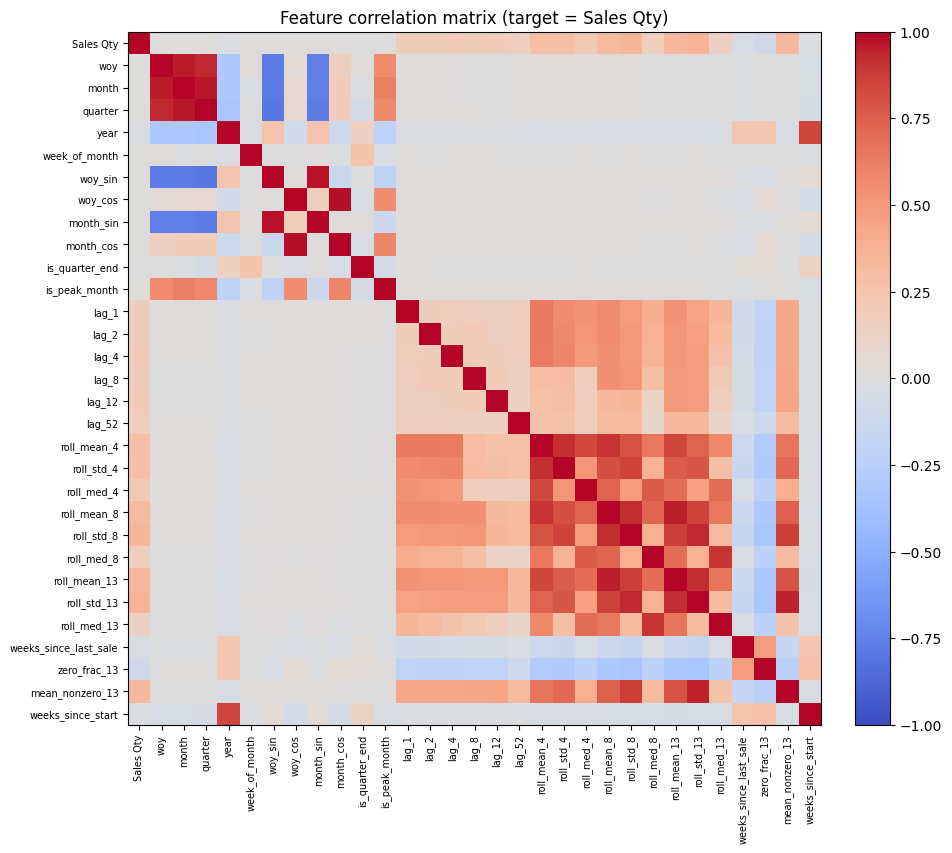

Top features by |correlation| with Sales Qty:
roll_std_13        0.352
roll_std_8         0.340
roll_mean_13       0.334
mean_nonzero_13    0.325
roll_mean_8        0.319
roll_mean_4        0.285
roll_std_4         0.275
roll_med_4         0.202


In [5]:
num = df[[config.COL_SALES_QTY] + [c for c in feats if df[c].dtype.kind in "fi"]]
corr = num.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("Feature correlation matrix (target = Sales Qty)")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

tgt = corr[config.COL_SALES_QTY].drop(config.COL_SALES_QTY).abs().sort_values(ascending=False)
print("Top features by |correlation| with Sales Qty:")
print(corr[config.COL_SALES_QTY][tgt.head(8).index].round(3).to_string())

## Save

Written to `data/processed/feature_table.parquet` (csv fallback).

In [6]:
p = fe.save_feature_table(df)
print("saved:", p)

saved: /home/claude/cinnamon_sales_forecasting/data/processed/feature_table.parquet


## Hand-off to step 4

The feature table feeds the **global LightGBM** that will serve Tiers A and B.
Step 4 will:
* split by time (rolling backtest, last-12-weeks holdout),
* train baselines (naïve, seasonal-naïve, moving average, Croston/TSB),
* train the global LightGBM on this table,
* compare per tier with WAPE / MASE,
and route Tier C to a simple baseline (no features needed).